Using device: cpu
Vocab sizes: {'Usage': 19, 'VehType': 16, 'VehPower': 9}
Train / Val / Test: 49,974 / 10,709 / 10,709

[CHECK] Numeric features used: Expo only (YearGap dropped)

Model created. Total parameters: 88,449

pos_weight for BCE loss: 6.89
Epoch  1/10 | train_loss: 1.0148 | val_loss: 1.0068
Epoch  2/10 | train_loss: 1.0030 | val_loss: 1.0049
Epoch  3/10 | train_loss: 1.0002 | val_loss: 1.0095
Epoch  4/10 | train_loss: 0.9972 | val_loss: 1.0086
Epoch  5/10 | train_loss: 0.9967 | val_loss: 1.0039
Epoch  6/10 | train_loss: 0.9964 | val_loss: 1.0048
Epoch  7/10 | train_loss: 0.9953 | val_loss: 1.0017
Epoch  8/10 | train_loss: 0.9946 | val_loss: 1.0012
Epoch  9/10 | train_loss: 0.9931 | val_loss: 1.0012
Epoch 10/10 | train_loss: 0.9931 | val_loss: 1.0030


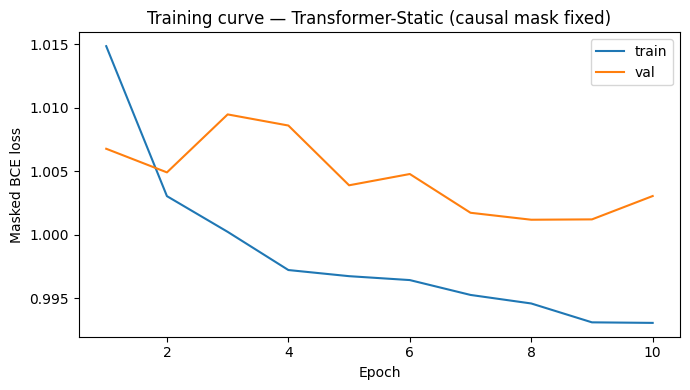


===== Test set evaluation (timestep-level) =====
Total timestep predictions: 54,755
AUC-ROC : 0.7664
F1-score: 0.3646
Positive rate in test: 12.79%

Best threshold : 0.620
Best F1-score  : 0.3772
  Precision    : 0.3019
  Recall       : 0.5025

Saved: data/sequences/transformer_static_model_fixed.pt
Saved: data/sequences/transformer_static_test_predictions_fixed.npz

===== Transformer-Static (Model ③, causal-mask fixed) Summary =====
Architecture          : 2-layer Transformer Encoder, emb_dim=64, n_heads=4
Causal mask            : ADDED (fix)
Numeric features        : Expo only (YearGap REMOVED)
Total parameters        : 88,449
Test AUC-ROC            : 0.7664
Test F1-score(best)     : 0.3772


In [2]:
# ============================================================
# Notebook    : 04a_transformer_static.ipynb (REVISED)
# Description : Case A extension — Model ③ Transformer-Static,
#               RE-RUN with causal attention mask (same fix as
#               03_transformer_longitudinal.ipynb).
#
#               Two changes from the original 04a:
#                 1. Causal mask added (bug fix, see 03 header)
#                 2. Mask dtype aligned (float, matching
#                    generate_square_subsequent_mask's output)
#                    to avoid the "mismatched mask dtype"
#                    deprecation warning seen in 03's re-run
# ============================================================


# ============================================================
# 0. Install dependencies (run once)
# ============================================================
# pip install torch scikit-learn matplotlib


# ============================================================
# 1. Common imports
# ============================================================
import pickle
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cpu")
print("Using device:", DEVICE)


# ============================================================
# 2. Load sequences and vocabularies built in notebook 02
# ============================================================
with open("data/sequences/train_sequences.pkl", "rb") as f:
    train_seqs = pickle.load(f)
with open("data/sequences/val_sequences.pkl", "rb") as f:
    val_seqs = pickle.load(f)
with open("data/sequences/test_sequences.pkl", "rb") as f:
    test_seqs = pickle.load(f)

with open("data/sequences/vocabs.json", "r", encoding="utf-8") as f:
    vocabs = json.load(f)

vocab_sizes = {k: len(v) for k, v in vocabs.items()}
print("Vocab sizes:", vocab_sizes)
print(f"Train / Val / Test: {len(train_seqs):,} / {len(val_seqs):,} / {len(test_seqs):,}")


# ============================================================
# 3. Dataset and collate function — same Expo-only slicing as
#    original 04a
# ============================================================
NUMERIC_COL_IDX = [0]  # index 0 = Expo, index 1 = YearGap (dropped)

class SequenceDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, idx):
        return self.sequences[idx]

def collate_fn(batch):
    max_len = max(item["length"] for item in batch)
    batch_size = len(batch)
    n_numeric = len(NUMERIC_COL_IDX)
    n_cat     = batch[0]["cat_idx"].shape[1]

    numeric_padded = torch.zeros(batch_size, max_len, n_numeric, dtype=torch.float32)
    cat_idx_padded = torch.zeros(batch_size, max_len, n_cat, dtype=torch.long)
    label_padded   = torch.zeros(batch_size, max_len, dtype=torch.float32)
    attention_mask = torch.zeros(batch_size, max_len, dtype=torch.bool)

    for i, item in enumerate(batch):
        L = item["length"]
        numeric_slice = item["numeric"][:, NUMERIC_COL_IDX]
        numeric_padded[i, :L] = torch.tensor(numeric_slice)
        cat_idx_padded[i, :L] = torch.tensor(item["cat_idx"])
        label_padded[i, :L]   = torch.tensor(item["label"], dtype=torch.float32)
        attention_mask[i, :L] = True

    return {
        "numeric": numeric_padded,
        "cat_idx": cat_idx_padded,
        "label":   label_padded,
        "mask":    attention_mask,
    }

BATCH_SIZE = 32

train_loader = DataLoader(SequenceDataset(train_seqs), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(SequenceDataset(val_seqs),   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(SequenceDataset(test_seqs),  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"\n[CHECK] Numeric features used: Expo only (YearGap dropped)")


# ============================================================
# 4. Model definition — CAUSAL MASK ADDED, dtype-aligned
#    - src_key_padding_mask converted to float (-inf/0) so both
#      masks passed to the encoder share dtype, avoiding the
#      PyTorch deprecation warning
# ============================================================
class TimestepRiskTransformer(nn.Module):
    def __init__(self, vocab_sizes, n_numeric, emb_dim=64, n_heads=4,
                 n_layers=2, ff_dim=128, dropout=0.1):
        super().__init__()

        cat_cols = list(vocab_sizes.keys())
        self.cat_cols = cat_cols

        self.embeddings = nn.ModuleDict({
            col: nn.Embedding(vocab_sizes[col], emb_dim, padding_idx=0)
            for col in cat_cols
        })

        self.numeric_proj = nn.Linear(n_numeric, emb_dim)

        combined_dim = emb_dim * (len(cat_cols) + 1)
        self.input_proj = nn.Linear(combined_dim, emb_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, emb_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim // 2, 1),
        )

    def forward(self, numeric, cat_idx, attention_mask):
        cat_embeds = []
        for i, col in enumerate(self.cat_cols):
            cat_embeds.append(self.embeddings[col](cat_idx[:, :, i]))
        cat_embeds = torch.cat(cat_embeds, dim=-1)

        num_embed = self.numeric_proj(numeric)

        combined = torch.cat([cat_embeds, num_embed], dim=-1)
        x = self.input_proj(combined)

        # CAUSAL MASK — bug fix (see notebook header)
        T = x.size(1)
        causal_mask = nn.Transformer.generate_square_subsequent_mask(T).to(x.device)
        # causal_mask dtype is float (0 / -inf); align padding mask
        # to the same dtype/convention to avoid PyTorch's
        # mismatched-mask-dtype deprecation warning
        padding_mask_float = torch.zeros_like(attention_mask, dtype=torch.float32)
        padding_mask_float.masked_fill_(~attention_mask, float("-inf"))

        encoded = self.encoder(
            x,
            mask=causal_mask,
            src_key_padding_mask=padding_mask_float,
        )

        logits = self.classifier(encoded).squeeze(-1)
        return logits


N_NUMERIC = 1  # Expo only, YearGap removed
model = TimestepRiskTransformer(vocab_sizes=vocab_sizes, n_numeric=N_NUMERIC).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nModel created. Total parameters: {n_params:,}")


# ============================================================
# 5. Loss function — UNCHANGED
# ============================================================
POS_WEIGHT = torch.tensor((1 - 0.1267) / 0.1267)
print(f"\npos_weight for BCE loss: {POS_WEIGHT.item():.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT, reduction="none")

def masked_bce_loss(logits, labels, mask):
    loss = criterion(logits, labels)
    loss = loss * mask.float()
    return loss.sum() / mask.float().sum()


# ============================================================
# 6. Training loop — UNCHANGED
# ============================================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
N_EPOCHS = 10

train_losses, val_losses = [], []

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    epoch_train_loss = 0.0
    n_batches = 0

    for batch in train_loader:
        numeric = batch["numeric"].to(DEVICE)
        cat_idx = batch["cat_idx"].to(DEVICE)
        label   = batch["label"].to(DEVICE)
        mask    = batch["mask"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(numeric, cat_idx, mask)
        loss = masked_bce_loss(logits, label, mask)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()
        n_batches += 1

    avg_train_loss = epoch_train_loss / n_batches
    train_losses.append(avg_train_loss)

    model.eval()
    epoch_val_loss = 0.0
    n_val_batches = 0
    with torch.no_grad():
        for batch in val_loader:
            numeric = batch["numeric"].to(DEVICE)
            cat_idx = batch["cat_idx"].to(DEVICE)
            label   = batch["label"].to(DEVICE)
            mask    = batch["mask"].to(DEVICE)

            logits = model(numeric, cat_idx, mask)
            loss = masked_bce_loss(logits, label, mask)
            epoch_val_loss += loss.item()
            n_val_batches += 1

    avg_val_loss = epoch_val_loss / n_val_batches
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch:2d}/{N_EPOCHS} | train_loss: {avg_train_loss:.4f} | val_loss: {avg_val_loss:.4f}")


# ============================================================
# 7. Plot
# ============================================================
plt.figure(figsize=(7, 4))
plt.plot(range(1, N_EPOCHS + 1), train_losses, label="train")
plt.plot(range(1, N_EPOCHS + 1), val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("Masked BCE loss")
plt.title("Training curve — Transformer-Static (causal mask fixed)")
plt.legend()
plt.tight_layout()
plt.savefig("data/sequences/training_curve_static_fixed.png")
plt.show()


# ============================================================
# 8. Evaluation — UNCHANGED convention
# ============================================================
model.eval()
all_logits, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        numeric = batch["numeric"].to(DEVICE)
        cat_idx = batch["cat_idx"].to(DEVICE)
        label   = batch["label"].to(DEVICE)
        mask    = batch["mask"].to(DEVICE)

        logits = model(numeric, cat_idx, mask)

        flat_logits = logits[mask]
        flat_labels = label[mask]

        all_logits.append(flat_logits.numpy())
        all_labels.append(flat_labels.numpy())

all_logits = np.concatenate(all_logits)
all_labels = np.concatenate(all_labels)
all_probs  = 1 / (1 + np.exp(-all_logits))

auc = roc_auc_score(all_labels, all_probs)
f1  = f1_score(all_labels, (all_probs >= 0.5).astype(int))

print("\n===== Test set evaluation (timestep-level) =====")
print(f"Total timestep predictions: {len(all_labels):,}")
print(f"AUC-ROC : {auc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Positive rate in test: {all_labels.mean()*100:.2f}%")

precisions, recalls, thresholds = precision_recall_curve(all_labels, all_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores[:-1])
print(f"\nBest threshold : {thresholds[best_idx]:.3f}")
print(f"Best F1-score  : {f1_scores[best_idx]:.4f}")
print(f"  Precision    : {precisions[best_idx]:.4f}")
print(f"  Recall       : {recalls[best_idx]:.4f}")


# ============================================================
# 9. Save
# ============================================================
torch.save(model.state_dict(), "data/sequences/transformer_static_model_fixed.pt")
print("\nSaved: data/sequences/transformer_static_model_fixed.pt")

np.savez(
    "data/sequences/transformer_static_test_predictions_fixed.npz",
    logits=all_logits,
    labels=all_labels,
    probs=all_probs,
)
print("Saved: data/sequences/transformer_static_test_predictions_fixed.npz")


# ============================================================
# 10. Summary
# ============================================================
print("\n===== Transformer-Static (Model ③, causal-mask fixed) Summary =====")
print(f"Architecture          : 2-layer Transformer Encoder, emb_dim=64, n_heads=4")
print(f"Causal mask            : ADDED (fix)")
print(f"Numeric features        : Expo only (YearGap REMOVED)")
print(f"Total parameters        : {n_params:,}")
print(f"Test AUC-ROC            : {auc:.4f}")
print(f"Test F1-score(best)     : {f1_scores[best_idx]:.4f}")
print("======================================")